<a href="https://colab.research.google.com/github/LFelipeMartins-stack/analise_exploratoria_titanic/blob/main/src/analise_exploratoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [342]:
## Etapa 1: Importação e Compreensão de Dados - INÍCIO

In [343]:
import pandas as pd #Importando pandas para manipulação, limpeza e análise de dados.

In [344]:
import matplotlib.pyplot as plt #Criar e personalizar gráficos de forma rápida e intuitiva

In [345]:
import seaborn as sns #Utilizada para criar gráficos atraentes, informativos e complexos com menos linhas de código

In [346]:
import matplotlib.ticker as mtick #formatador de eixos

In [388]:
try:
    url = 'https://raw.githubusercontent.com/LFelipeMartins-stack/analise_exploratoria_titanic/main/dados/titanic_dataset.csv'
    df = pd.read_csv(url)
    print("Dados carregados via GitHub com sucesso!\n")
except:
    # Fallback caso o link falhe: lê o arquivo local
    df = pd.read_csv('/content/titanic_dataset.csv')
    print("Dados carregados localmente.\n")

Dados carregados via GitHub com sucesso!



In [348]:
df.head() #Visualizando as cinco primeiras linhas do Dataframe de forma limpa no google_colab

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [349]:
df.info() #Visualizando resumo técnico e conciso de um DataFrame de forma limpa no google_colab

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [350]:
df.describe() #Visualizando estatísticas descritivas resumidas de um DataFrame de forma limpa no google_colab

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [351]:
## Etapa 1: Importação e Compreensão de Dados - FIM

In [352]:
## Etapa 2: Limpeza e Tratamento de Dados - INÍCIO

In [353]:
duplicateRows = df[df.duplicated()] #Criando variável para identificar valores duplicados no dataset

In [354]:
print("Valores duplicados ANTES do tratamento:")
print(len(duplicateRows))

Valores duplicados ANTES do tratamento:
0


In [355]:
print("Valores nulos ANTES do tratamento:")
display(df.isnull().sum())

Valores nulos ANTES do tratamento:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [356]:
mediana_idade = df['Age'].median()
df['Age'] = df['Age'].fillna(mediana_idade) #Para a idade resolvi calcular a mediana e preencher os valores vazios com ela. Mediana usada ao invés de média pois não sofre influência de idades extremas

In [357]:
df = df.drop(columns=['Cabin']) #Como faltam quase 80% dos dados da Cabine, ela se torna inútil para analise. Removida!

In [358]:
df = df.dropna(subset=['Embarked']) #Como faltam apenas 2 valores nessa coluna, removi as duas que estavam nulos.

In [359]:
remove_columns = ['PassengerId', 'Name', 'Ticket']
df = df.drop(columns=remove_columns) #PassengerId, Name e Ticket não têm relação causal com a sobrevivência da pessoa, então removi porque entendo que são desnecessários para analise de dados atual.

In [360]:
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category') #Transformação de tipo texto e número em categorias para economizar memória RAM e acelerar processo na hora de gerar gráficos Seaborn/Matplotlib.

In [361]:
df['Pclass'] = df['Pclass'].astype('category') #Transformando o Pclass como categoria também, primeira classe, segunda classe, evitando possiveis conflitos.

In [362]:
print("\nValores nulos DEPOIS do tratamento:")
display(df.isnull().sum())


Valores nulos DEPOIS do tratamento:


,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [363]:
## Etapa 2: Limpeza e Tratamento de Dados - FIM

In [364]:
## Etapa 3: Análises e Agrupamentos - INÍCIO

In [365]:
overall_survival_rate = df['Survived'].mean() * 100 #Percentual geral de sobrevivente

In [366]:
print(f"-> Taxa de sobrevivência GERAL do navio: {overall_survival_rate:.2f}%")


-> Taxa de sobrevivência GERAL do navio: 38.25%


In [367]:
survival_sex = df.groupby('Sex', observed=True)['Survived'].mean().reset_index() # Agrupamento por Sexo

In [368]:
survival_sex['Survived'] = (survival_sex['Survived'] * 100).round(2).astype(str) + '%'# Agrupamento por Sexo

In [369]:
survival_sex.columns = ['Gênero', 'Taxa de Sobrevivência']# Agrupamento por Sexo

In [370]:
survival_class = df.groupby('Pclass', observed=True)['Survived'].mean().reset_index() # Agrupamento por Classe

In [371]:
survival_class['Survived'] = (survival_class['Survived'] * 100).round(2).astype(str) + '%' # Agrupamento por Classe

In [372]:
survival_class.columns = ['Classe do Bilhete', 'Taxa de Sobrevivência'] # Agrupamento por Classe

In [373]:
cortes = [0, 17, 59, 100] #Separação de grupos por faixa etária

In [374]:
track_names = ['Menores (0-17)', 'Adultos (18-59)', 'Idosos (60+)'] # Agrupamento por Faixa Etária

In [375]:
df['Faixa_Etaria'] = pd.cut(df['Age'], bins=cortes, labels=track_names) # Agrupamento por Faixa Etária

In [376]:
survival_age = df.groupby('Faixa_Etaria', observed=True)['Survived'].mean().reset_index() # Agrupamento por Faixa Etária

In [377]:
survival_age['Survived'] = (survival_age['Survived'] * 100).round(2).astype(str) + '%' # Agrupamento por Faixa Etária

In [378]:
survival_age.columns = ['Faixa Etária', 'Taxa de Sobrevivência'] # Agrupamento por Faixa Etária

In [379]:
print("--- ANÁLISE POR GÊNERO ---")
display(survival_sex)

--- ANÁLISE POR GÊNERO ---


,Gênero,Taxa de Sobrevivência
0,female,74.04%
1,male,18.89%


In [380]:
print("\n--- ANÁLISE POR CLASSE SOCIAL ---")
display(survival_class)


--- ANÁLISE POR CLASSE SOCIAL ---


,Classe do Bilhete,Taxa de Sobrevivência
0,1,62.62%
1,2,47.28%
2,3,24.24%


In [381]:
print("\n--- ANÁLISE POR FAIXA ETÁRIA ---")
display(survival_age)


--- ANÁLISE POR FAIXA ETÁRIA ---


,Faixa Etária,Taxa de Sobrevivência
0,Menores (0-17),53.98%
1,Adultos (18-59),36.35%
2,Idosos (60+),24.0%


In [382]:
## Etapa 3: Análises e Agrupamentos - FIM

In [383]:
## Etapa 4: Visualização de Dados Graficamente - INÍCIO

In [384]:
sns.set_theme(style="whitegrid", palette="muted") # Estilo e paleta definidos

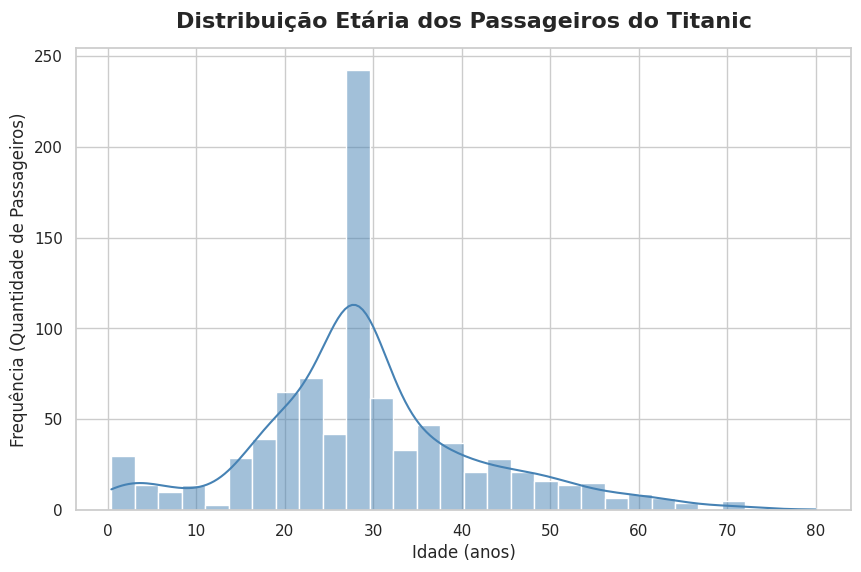

In [385]:
# GRÁFICO 1: Distribuição da Idade (Histograma)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', bins=30, kde=True, color='steelblue')
plt.title('Distribuição Etária dos Passageiros do Titanic', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Idade (anos)', fontsize=12)
plt.ylabel('Frequência (Quantidade de Passageiros)', fontsize=12)
plt.show()


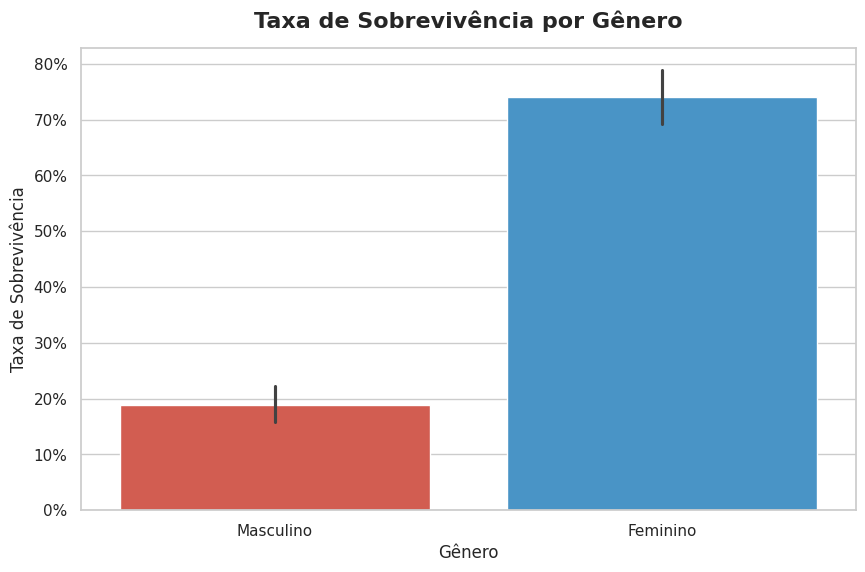

In [386]:
# GRÁFICO 2: Relação entre Sexo e Sobrevivência (Gráfico de Barras)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df,
    x='Sex',
    y='Survived',
    hue='Sex',
    legend=False,
    order=['male', 'female'],
    palette=['#3498db', '#e74c3c'])
plt.title('Taxa de Sobrevivência por Gênero', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Gênero', fontsize=12)
plt.ylabel('Taxa de Sobrevivência', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Masculino', 'Feminino'])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)) #Transformando o eixe em porcentagem
plt.show()


In [387]:
## Etapa 4: Visualização de Dados Graficamente - FIM